<a href="https://colab.research.google.com/github/Semedw/TED-view-prediction-model/blob/main/notebooke9387ddd49.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import ast

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

import xgboost as xgb
import lightgbm as lgb
from xgboost.callback import EarlyStopping


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
train = pd.read_csv("train.csv", index_col=0)
test = pd.read_csv("test.csv", index_col=0)

In [ ]:
train

,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views,id
1601,How do we solve the problem of the suburbs? Ur...,1016,TEDCity2.0,1379635200,26,Jeff Speck,Jeff Speck: The walkable city,1,1381763957,"[{'id': 26, 'name': 'Obnoxious', 'count': 10},...","[{'id': 1838, 'hero': 'https://pe.tedcdn.com/i...",Urban planner,"['cities', 'culture', 'design', 'transportation']",The walkable city,https://www.ted.com/talks/jeff_speck_the_walka...,1147783,1601
1200,"""Secrets can take many forms -- they can be sh...",684,TED2012,1330473600,40,Frank Warren,Frank Warren: Half a million secrets,1,1333984091,"[{'id': 9, 'name': 'Ingenious', 'count': 298},...","[{'id': 144, 'hero': 'https://pe.tedcdn.com/im...",Secret keeper,"['community', 'creativity', 'design', 'memory'...",Half a million secrets,https://www.ted.com/talks/frank_warren_half_a_...,3150673,1200
1340,The open-source world has learned to deal with...,1112,TEDGlobal 2012,1340668800,24,Clay Shirky,Clay Shirky: How the Internet will (one day) t...,1,1348584705,"[{'id': 24, 'name': 'Persuasive', 'count': 349...","[{'id': 1329, 'hero': 'https://pe.tedcdn.com/i...",Social Media Theorist,"['Internet', 'collaboration', 'future', 'gover...",How the Internet will (one day) transform gove...,https://www.ted.com/talks/clay_shirky_how_the_...,1217691,1340
2492,Born with a genetic visual impairment that has...,467,TED Residency,1481587200,16,Susan Robinson,Susan Robinson: How I fail at being disabled,1,1500649053,"[{'id': 3, 'name': 'Courageous', 'count': 34},...","[{'id': 2594, 'hero': 'https://pe.tedcdn.com/i...","Business executive, entrepreneur","['Blindness', 'TED Residency', 'disability', '...",How I fail at being disabled,https://www.ted.com/talks/susan_robinson_how_i...,931593,2492
2233,"What makes you, you? Psychologists like to tal...",915,TED2016,1455580800,29,Brian Little,"Brian Little: Who are you, really? The puzzle ...",1,1466694337,"[{'id': 25, 'name': 'OK', 'count': 214}, {'id'...","[{'id': 1377, 'hero': 'https://pe.tedcdn.com/i...",Personality researcher,"['TED Books', 'communication', 'humanity', 'hu...","Who are you, really? The puzzle of personality",https://www.ted.com/talks/brian_little_who_are...,4287882,2233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,"""An advanced city is not one where even the po...",857,TEDCity2.0,1379635200,29,Enrique Peñalosa,Enrique Peñalosa: Why buses represent democrac...,1,1386345659,"[{'id': 9, 'name': 'Ingenious', 'count': 162},...","[{'id': 1182, 'hero': 'https://pe.tedcdn.com/i...","Colombian politician, urban activist","['South America', 'cities', 'design', 'infrast...",Why buses represent democracy in action,https://www.ted.com/talks/enrique_penalosa_why...,847830,1638
1095,Every morning we wake up and regain consciousn...,1122,TED2011,1299024000,32,Antonio Damasio,Antonio Damasio: The quest to understand consc...,1,1324310558,"[{'id': 8, 'name': 'Informative', 'count': 740...","[{'id': 102, 'hero': 'https://pe.tedcdn.com/im...",Neuroscientist,"['Senses', 'brain', 'cognitive science', 'cons...",The quest to understand consciousness,https://www.ted.com/talks/antonio_damasio_the_...,1857965,1095
1130,What if you're in surgery and the power goes o...,683,TEDxMidAtlantic,1322784000,27,Erica Frenkel,Erica Frenkel: The universal anesthesia machine,1,1328200107,"[{'id': 24, 'name': 'Persuasive', 'count': 44}...","[{'id': 268, 'hero': 'https://pe.tedcdn.com/im...",Medical technologist,"['Surgery', 'TEDx', 'design', 'global issues',...",The universal anesthesia machine,https://www.ted.com/talks/erica_frenkel_the_un...,232818,1130
1294,Two-thirds of the world may not have access to...,848,TEDxSummit,1334793600,21,Vinay Venkatraman,Vinay Venkatraman: Technology crafts for the d...,1,1342969159,"[{'id': 22, 'name': 'Fascinating', 'count': 83...","[{'id': 1348, 'hero': 'https://pe.tedcdn.com/i...",Designer,"['TEDx', 'global

In [ ]:
train['views'].describe()

,views
count,2.040000e+03
mean,1.717260e+06
std,2.613108e+06
min,-2.446000e+03
25%,7.625882e+05
50%,1.147979e+06
75%,1.753105e+06
max,4.704636e+07


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


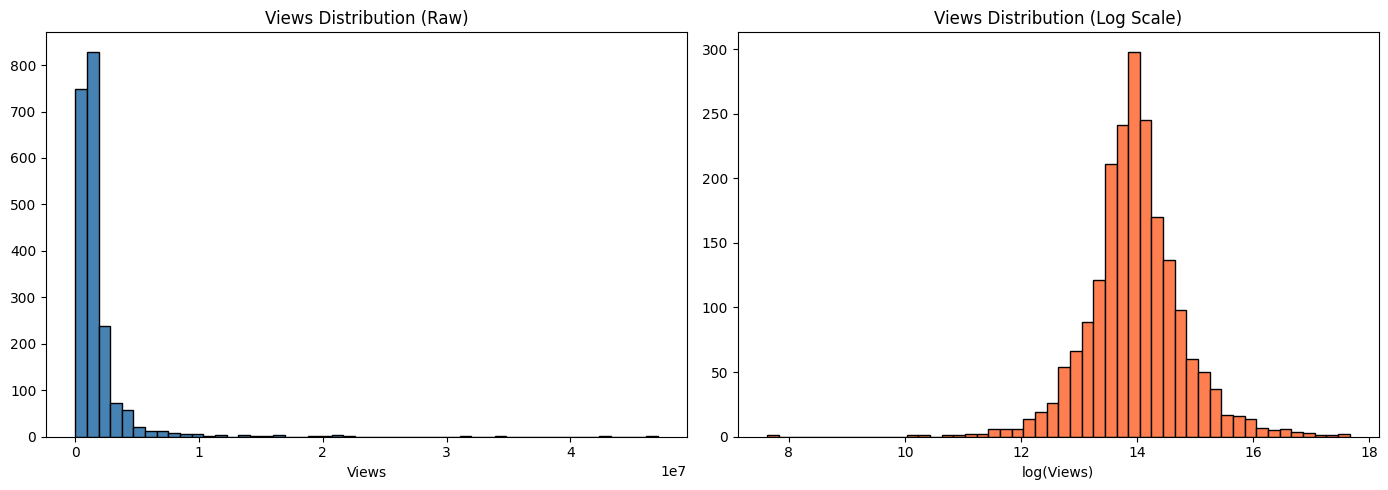

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['views'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Views Distribution (Raw)')
axes[0].set_xlabel('Views')

axes[1].hist(np.log1p(train['views']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Views Distribution (Log Scale)')
axes[1].set_xlabel('log(Views)')

plt.tight_layout()
plt.show()

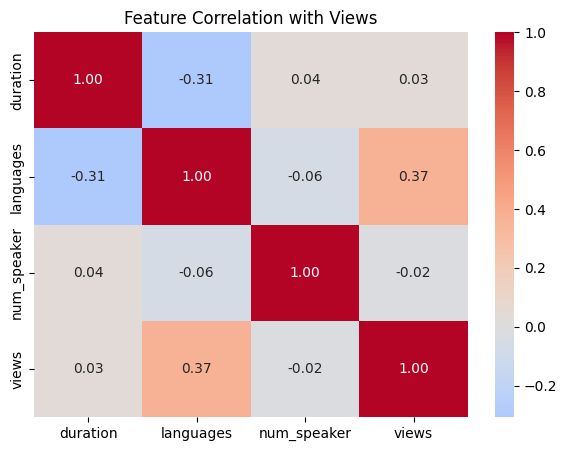

In [ ]:
num_cols = ['duration', 'languages', 'num_speaker', 'views']
corr = train[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation with Views')
plt.show()

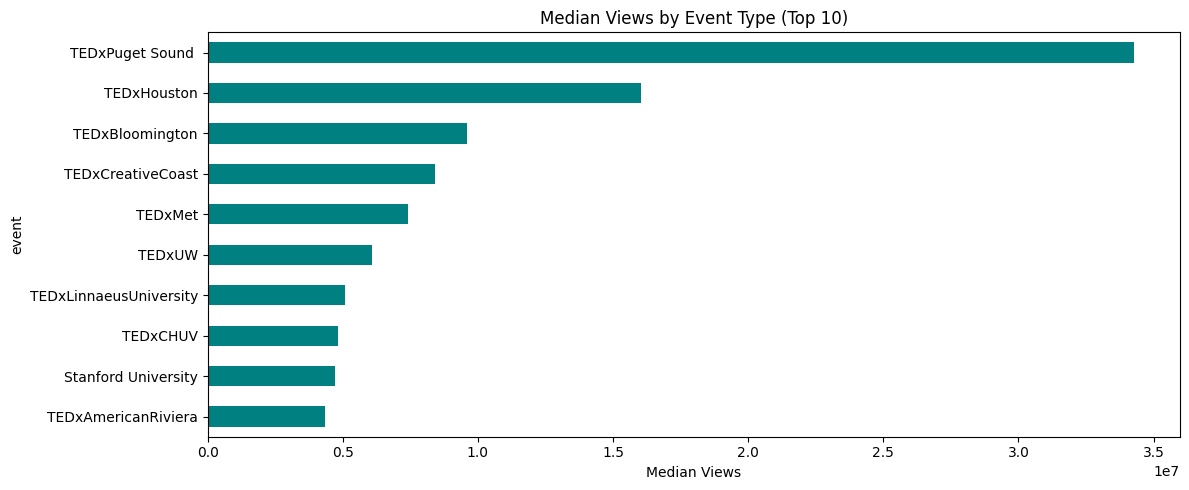

In [ ]:
top_events = train.groupby('event')['views'].median().nlargest(10)

plt.figure(figsize=(12, 5))
top_events.sort_values().plot(kind='barh', color='teal')
plt.title('Median Views by Event Type (Top 10)')
plt.xlabel('Median Views')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


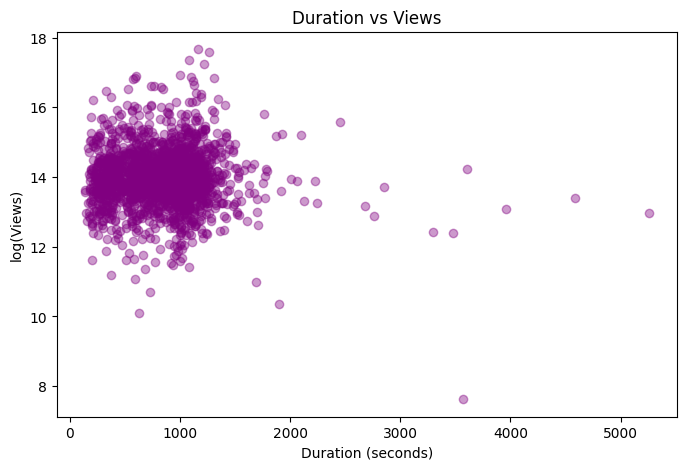

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(train['duration'], np.log1p(train['views']), alpha=0.4, color='purple')
plt.xlabel('Duration (seconds)')
plt.ylabel('log(Views)')
plt.title('Duration vs Views')
plt.show()

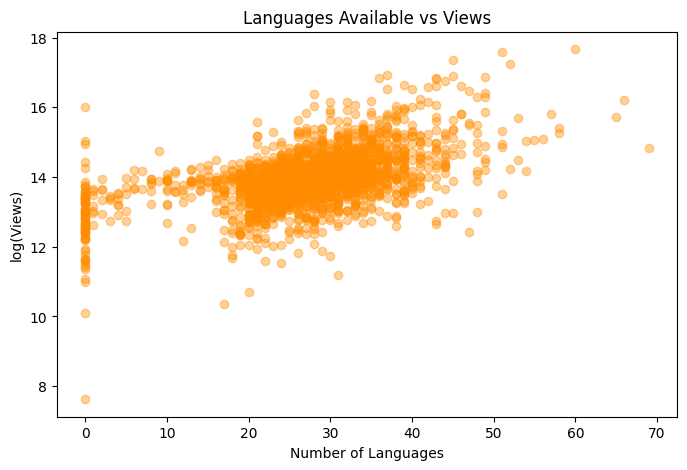

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(train['languages'], np.log1p(train['views']), alpha=0.4, color='darkorange')
plt.xlabel('Number of Languages')
plt.ylabel('log(Views)')
plt.title('Languages Available vs Views')
plt.show()

In [ ]:
train['log_views'] = np.log1p(train['views'])

In [ ]:
print("Rows with negative views:", (train['views'] < 0).sum())
train = train[train['views'] > 0].reset_index(drop=True)
print("Train size after removing bad rows:", len(train))

Rows with negative views: 1
Train size after removing bad rows: 2039


In [ ]:
# Outside add_features, after calling it:
max_pub = train['published_date'].max()
train['days_since_published'] = (max_pub - train['published_date']) / 86400
test['days_since_published']  = (max_pub - test['published_date']) / 86400

In [ ]:
def get_tag_count(r, tag):
      try:
          ratings = ast.literal_eval(r)
          for x in ratings:
              if x['name'] == tag:
                  return x['count']
          return 0
      except:
          return 0

In [ ]:
def add_features(df):
    d = df.copy()

    # Convert unix timestamps to year
    d['film_year']      = pd.to_datetime(d['film_date'],      unit='s').dt.year
    d['published_year'] = pd.to_datetime(d['published_date'], unit='s').dt.year

    # How many days between filming and publishing?
    d['days_to_publish'] = (d['published_date'] - d['film_date']) / 86400

    # Duration in minutes instead of seconds
    d['duration_min'] = d['duration'] / 60

    # Parse ratings column (it's a string that looks like a list of dicts)
    def get_total_ratings(r):
        try:
            return sum(x['count'] for x in ast.literal_eval(r))
        except:
            return 0

    d['total_ratings'] = d['ratings'].apply(get_total_ratings)

    tags = ['Inspiring', 'Funny', 'Beautiful', 'Informative',
        'Fascinating', 'Courageous', 'Persuasive', 'Confusing', 'Longwinded']

    for tag in tags:
        d[f'rating_{tag.lower()}'] = d['ratings'].apply(lambda r: get_tag_count(r, tag))

    # Number of tags
    d['num_tags'] = d['tags'].apply(
        lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0
    )

    # Is it a TEDx talk (usually fewer views than main TED)?
    d['is_tedx'] = d['event'].str.contains('TEDx', na=False).astype(int)

    # Speaker popularity proxy (how many talks does this speaker have?)
    speaker_counts = df['main_speaker'].value_counts()
    d['speaker_talk_count'] = d['main_speaker'].map(speaker_counts)

    # Ratings breakdown: % positive (inspiring, funny, etc.) vs. negative
    def get_positive_rating_ratio(r):
        try:
            ratings = ast.literal_eval(r)
            positive = {'Inspiring', 'Funny', 'Beautiful', 'Informative', 'Fascinating', 'Courageous', 'Persuasive'}
            pos = sum(x['count'] for x in ratings if x['name'] in positive)
            total = sum(x['count'] for x in ratings)
            return pos / total if total > 0 else 0
        except:
            return 0
    d['positive_ratio'] = d['ratings'].apply(get_positive_rating_ratio)

    # Title length (catchier titles may drive more clicks)
    d['title_len'] = d['title'].str.len()

    d['published_month'] = pd.to_datetime(d['published_date'], unit='s').dt.month
    d['published_dayofweek'] = pd.to_datetime(d['published_date'], unit='s').dt.dayofweek

    # Description word count
    d['desc_word_count'] = d['description'].fillna('').str.split().str.len()



    return d


train = add_features(train)
test  = add_features(test)

print('Features added!')
print(train[['duration_min', 'film_year', 'days_to_publish', 'total_ratings', 'num_tags', 'is_tedx']].head(3))

Features added!
   duration_min  film_year  days_to_publish  total_ratings  num_tags  is_tedx
0     16.933333       2013        24.638391           1151         4        0
1     11.400000       2012        40.630683           3756         5        0
2     18.533333       2012        91.619271           1685        10        0


In [ ]:
def target_encode(train, test, col, target):
    global_mean = train[target].mean()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    train_encoded = np.zeros(len(train))

    for tr_idx, val_idx in kf.split(train):
        means = train.iloc[tr_idx].groupby(col)[target].mean()
        train_encoded[val_idx] = train.iloc[val_idx][col].map(means).fillna(global_mean)

    test_encoded = train.groupby(col)[target].mean()
    test[col + '_target_enc'] = test[col].map(test_encoded).fillna(global_mean)
    train[col + '_target_enc'] = train_encoded
    return train, test

train, test = target_encode(train, test, 'event', 'log_views')
train, test = target_encode(train, test, 'main_speaker', 'log_views')

In [ ]:
NUM_COLS = [
    'duration_min', 'languages', 'num_speaker',
    'film_year', 'published_year', 'days_to_publish',
    'total_ratings', 'num_tags', 'is_tedx',
    'speaker_talk_count', 'days_since_published',
    'positive_ratio', 'title_len',
    # New columns
    'published_month', 'published_dayofweek', 'desc_word_count',
    'event_target_enc', 'main_speaker_target_enc',
    'rating_inspiring', 'rating_funny', 'rating_beautiful',
    'rating_informative', 'rating_fascinating', 'rating_courageous',
    'rating_persuasive', 'rating_confusing', 'rating_longwinded'
]

X_num_train = train[NUM_COLS].fillna(0).values
X_num_test  = test[NUM_COLS].fillna(0).values

# Scale to mean=0 std=1 so the network trains faster
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_test  = scaler.transform(X_num_test)


# Add title TF-IDF alongside description TF-IDF
tfidf_title = TfidfVectorizer(max_features=500, stop_words='english')
X_title_train = tfidf_title.fit_transform(train['title'].fillna('')).toarray()
X_title_test  = tfidf_title.transform(test['title'].fillna('')).toarray()

# TF-IDF on description text
tfidf = TfidfVectorizer(max_features=300, stop_words='english')
X_text_train = tfidf.fit_transform(train['description'].fillna('')).toarray()
X_text_test  = tfidf.transform(test['description'].fillna('')).toarray()

# Replace any remaining inf values with 0
X_num_train = np.nan_to_num(X_num_train, nan=0.0, posinf=0.0, neginf=0.0)
X_num_test  = np.nan_to_num(X_num_test,  nan=0.0, posinf=0.0, neginf=0.0)

# Combine them side by side
X_train = np.hstack([X_num_train, X_text_train, X_title_train]).astype(np.float32)
X_test  = np.hstack([X_num_test,  X_text_test,  X_title_test]).astype(np.float32)

# Target: log(views)
y = np.log1p(train['views'].values).astype(np.float32)

print(f'X_train shape: {X_train.shape}')   # (2040, 309)
print(f'y shape:       {y.shape}')

X_train shape: (2039, 827)
y shape:       (2039,)


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y, test_size=0.2, random_state=42)

# Convert numpy arrays to PyTorch tensors (think of them as numpy arrays that can run on GPU)
X_tr_t  = torch.tensor(X_tr)
y_tr_t  = torch.tensor(y_tr).view(-1, 1)   # .view(-1,1) reshapes from (N,) to (N,1)
X_val_t = torch.tensor(X_val)
y_val_t = torch.tensor(y_val).view(-1, 1)

# DataLoader feeds data in batches during training (like a generator)
loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

print(f'Train: {X_tr.shape[0]} rows | Val: {X_val.shape[0]} rows')

Train: 1631 rows | Val: 408 rows


In [ ]:
INPUT_SIZE = X_train.shape[1]  # 309

class ResidualBlock(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
        )
    def forward(self, x):
        return nn.functional.gelu(x + self.block(x))

class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.input_proj = nn.Linear(input_size, 256)
        self.res1 = ResidualBlock(256)
        self.res2 = ResidualBlock(256)
        self.head = nn.Linear(256, 1)

    def forward(self, x):
        x = nn.functional.gelu(self.input_proj(x))
        x = self.res1(x)
        x = self.res2(x)
        return self.head(x)

model = MLP(INPUT_SIZE)

print(model)

MLP(
  (input_proj): Linear(in_features=827, out_features=256, bias=True)
  (res1): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (res2): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (head): Linear(in_features

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS   = 800    # was 400
PATIENCE = 100    # was 50

criterion = nn.HuberLoss(delta=1.0)          # was MSELoss
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val = float('inf')
patience_counter = 0
train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):

    model.train()
    batch_losses = []
    for batch_X, batch_y in loader:
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_train = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        avg_val  = criterion(val_pred, y_val_t).item()

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    if np.isnan(avg_train) or np.isinf(avg_train):
        print(f"Loss exploded at epoch {epoch}! Stopping.")
        break

    # ── NEW: scheduler + early stopping (inside the loop) ──
    scheduler.step()

    if avg_val < best_val:
        best_val = avg_val
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break
    # ───────────────────────────────────────────────────────

    if epoch % 25 == 0:
        print(f'Epoch {epoch}/{EPOCHS}  |  Train: {avg_train:.4f}  |  Val: {avg_val:.4f}')

# ── After the loop: load the best checkpoint ──
model.load_state_dict(torch.load('best_model.pt'))
print(f'\nLoaded best model with val loss: {best_val:.4f}')

Epoch 25/800  |  Train: 0.1545  |  Val: 0.1572
Epoch 50/800  |  Train: 0.0831  |  Val: 0.1064
Epoch 75/800  |  Train: 0.0755  |  Val: 0.1211
Epoch 100/800  |  Train: 0.0564  |  Val: 0.1182
Epoch 125/800  |  Train: 0.0328  |  Val: 0.1209
Epoch 150/800  |  Train: 0.0305  |  Val: 0.1189
Epoch 175/800  |  Train: 0.0310  |  Val: 0.1175
Early stopping at epoch 198

Loaded best model with val loss: 0.0970


In [ ]:
params = dict(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold+1}/5")
    model_fold = lgb.LGBMRegressor(**params)
    model_fold.fit(
        X_train[tr_idx], y[tr_idx],
        eval_set=[(X_train[val_idx], y[val_idx])],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )
    oof_preds[val_idx] = model_fold.predict(X_train[val_idx])
    test_preds += model_fold.predict(X_test) / 5

oof_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOOF RMSE: {oof_rmse:.4f}")

Fold 1/5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9297
[LightGBM] [Info] Number of data points in the train set: 1631, number of used features: 403
[LightGBM] [Info] Start training from score 13.983370
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 2/5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005397 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9317
[LightGBM] [Info] Number of data points in the train set: 1631, number of used features: 411
[LightGBM] [Info] Start training from score 13.972732
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 3/5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9327
[LightGBM] [Info] Number of data points in the train set: 1631, number of used features: 411
[LightGBM] [Info] Start training from score 13.979151
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 4/5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009484 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9303
[LightGBM] [Info] Number of data points in the train set: 1631, number of used features: 404
[LightGBM] [Info] Start training from score 13.952899
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 5/5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9336
[LightGBM] [Info] Number of data points in the train set: 1632, number of used features: 406
[LightGBM] [Info] Start training from score 13.976838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


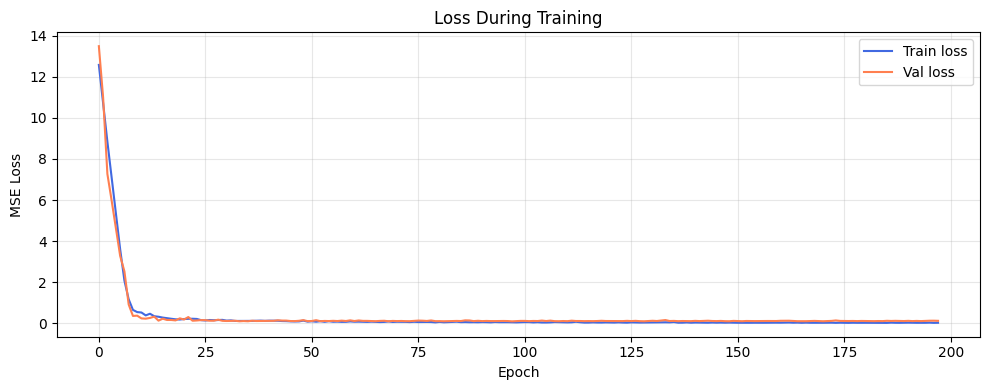

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train loss', color='royalblue')
plt.plot(val_losses,   label='Val loss',   color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss During Training')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

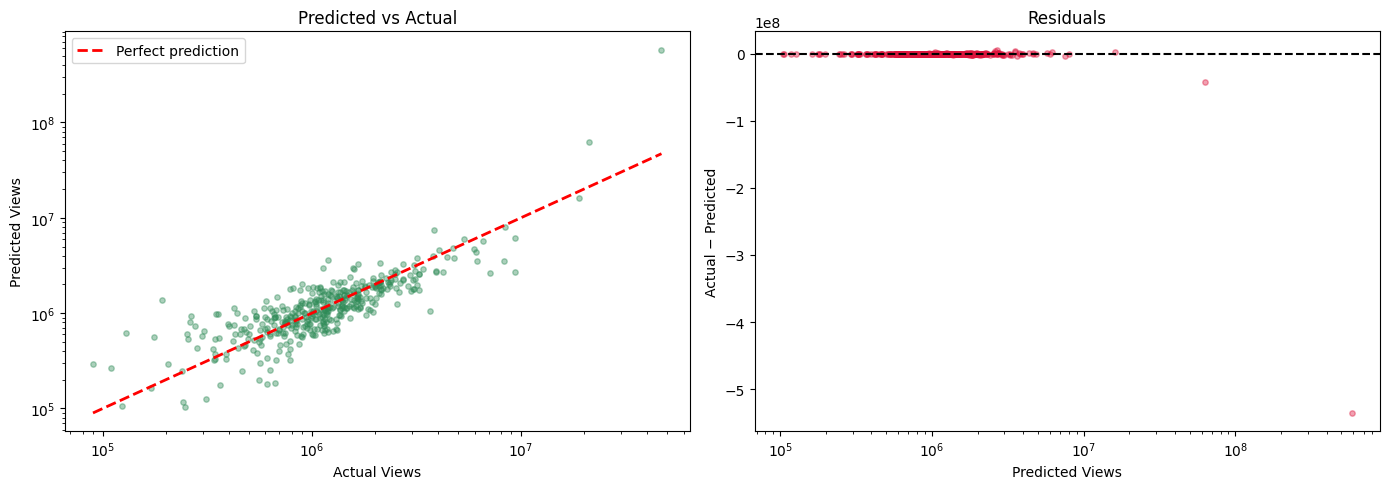

Validation RMSE (log scale): 0.4514


In [ ]:
model.eval()
with torch.no_grad():
    nn_preds_log = model(X_val_t).numpy().flatten()

# Convert log predictions back to actual view counts
actual    = np.expm1(y_val)
predicted = np.expm1(nn_preds_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: dots close to red line = accurate predictions
axes[0].scatter(actual, predicted, alpha=0.4, color='seagreen', s=15)
mn, mx = actual.min(), actual.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Actual Views'); axes[0].set_ylabel('Predicted Views')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Residuals: should be scattered randomly around 0
residuals = actual - predicted
axes[1].scatter(predicted, residuals, alpha=0.4, color='crimson', s=15)
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Predicted Views'); axes[1].set_ylabel('Actual − Predicted')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

# RMSE on log scale (lower is better; < 0.5 is good for this dataset)
rmse = np.sqrt(mean_squared_error(y_val, nn_preds_log))
print(f'Validation RMSE (log scale): {rmse:.4f}')

In [ ]:
# xgb_val_preds = xgb_model.predict(X_val)

# model.eval()
# with torch.no_grad():
#     nn_val_preds_log = model(X_val_t).numpy().flatten()

# print("Individual performance:")
# print(f"XGB  RMSE: {np.sqrt(mean_squared_error(y_val, xgb_val_preds)):.4f}")
# print(f"NN   RMSE: {np.sqrt(mean_squared_error(y_val, nn_val_preds_log)):.4f}")

# print("\nBlend search:")
# best_rmse, best_w = float('inf'), None
# for w in np.arange(0.1, 1.0, 0.1):
#     blend = w * xgb_val_preds + (1 - w) * nn_val_preds_log
#     rmse = np.sqrt(mean_squared_error(y_val, blend))
#     print(f"XGB weight {w:.1f} | NN weight {(1-w):.1f} | RMSE: {rmse:.4f}")
#     if rmse < best_rmse:
#         best_rmse, best_w = rmse, w

# print(f"\nBest blend: XGB={best_w:.1f}, NN={1-best_w:.1f} → RMSE: {best_rmse:.4f}")

In [ ]:
submission = pd.DataFrame({
    'id':    test['id'],
    'views': np.expm1(test_preds)
})
submission.to_csv('submission.csv', index=False)
print(submission.head())

        id         views
56      56  7.063947e+05
194    194  1.383628e+06
2225  2225  1.377843e+06
233    233  2.250585e+05
1902  1902  1.919425e+06
